# Stress Testing

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from scipy import stats
from sklearn.utils import resample
from sklearn.metrics import brier_score_loss
from scipy.stats import norm, binom
from scipy.integrate import quad
from scipy.special import logit, expit
from scipy.stats import spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
import matplotlib.patches as patches


In [2]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

Stress testing is often thought of something to limit risk or to comply with regulatory needs, however, it can also be valuable from a business perspective. It can be used to help set pricing and product features. It can be helpful to determine the spread above the risk-free rate when pricing loans. It also allows for the capture of the impact of exceptional but plausible loss events. VaR typically reflects everyday market behaviour. Stress testing looks into the tail of the loss distribution to study the impact of abnormal markets. It also allows for clearer picture of the risk profile of the firm. 


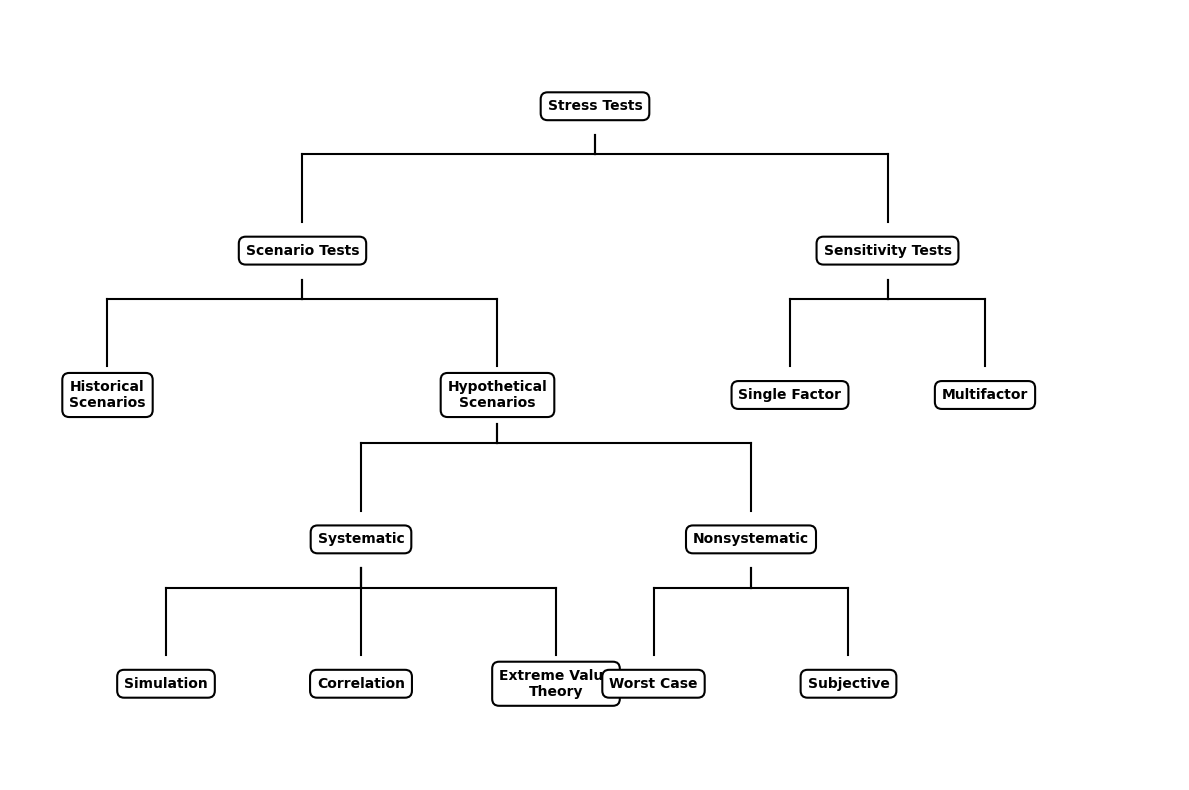

In [3]:
def draw_tree():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Styling settings
    box_props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=1.5)
    line_props = dict(color='black', linewidth=1.5, zorder=1)

    # Define node positions (x, y)
    nodes = {
        "Stress Tests": (0.5, 0.9),
        
        "Scenario Tests": (0.35, 0.75),
        "Sensitivity Tests": (0.65, 0.75),
        
        "Historical\nScenarios": (0.25, 0.6),
        "Hypothetical\nScenarios": (0.45, 0.6),
        "Single Factor": (0.6, 0.6),
        "Multifactor": (0.7, 0.6),
        
        "Systematic": (0.38, 0.45),
        "Nonsystematic": (0.58, 0.45),
        
        "Simulation": (0.28, 0.3),
        "Correlation": (0.38, 0.3),
        "Extreme Value\nTheory": (0.48, 0.3),
        "Worst Case": (0.53, 0.3),
        "Subjective": (0.63, 0.3)
    }

    # Draw boxes
    for text, pos in nodes.items():
        ax.text(pos[0], pos[1], text, ha='center', va='center', 
                bbox=box_props, fontsize=10, fontweight='bold')

    # Helper function for elbow lines
    def connect(parent, child, vert_drop=0.05):
        p_x, p_y = nodes[parent]
        c_x, c_y = nodes[child]
        
        # Draw vertical line down from parent, horizontal to child, vertical to child
        mid_y = p_y - vert_drop
        ax.plot([p_x, p_x], [p_y-0.03, mid_y], **line_props) # Down from parent
        ax.plot([p_x, c_x], [mid_y, mid_y], **line_props)    # Horizontal shift
        ax.plot([c_x, c_x], [mid_y, c_y+0.03], **line_props) # Down to child

    # Draw connections
    # Root to Level 1
    connect("Stress Tests", "Scenario Tests")
    connect("Stress Tests", "Sensitivity Tests")
    
    # Scenario level
    connect("Scenario Tests", "Historical\nScenarios")
    connect("Scenario Tests", "Hypothetical\nScenarios")
    
    # Sensitivity level
    connect("Sensitivity Tests", "Single Factor")
    connect("Sensitivity Tests", "Multifactor")
    
    # Hypothetical level
    connect("Hypothetical\nScenarios", "Systematic")
    connect("Hypothetical\nScenarios", "Nonsystematic")
    
    # Systematic level
    connect("Systematic", "Simulation")
    connect("Systematic", "Correlation")
    connect("Systematic", "Extreme Value\nTheory")
    
    # Nonsystematic level
    connect("Nonsystematic", "Worst Case")
    connect("Nonsystematic", "Subjective")

    # Cleanup plot
    ax.set_xlim(0.2, 0.8)
    ax.set_ylim(0.2, 1.0)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

draw_tree()

### Stress Testing Taxonomy
Stress testing evaluates financial resilience through two main lenses:

* **Sensitivity-Based:** A static approach used to gauge the immediate impact of specific variable changes. Typically used at the start of a risk exercise because they are easy to understand. However it is often difficult to logically connect these isolated changes to broader, real-world economic shifts.
    * **Single-Factor:** Varies one variable (e.g., a 100bps yield curve shift or a 5% drop in GDP) to see direct impact.
    * **Multifactor:** Varies multiple variables simultaneously. If these variables are correlated, the test effectively evolves into a "Scenario Test."
* **Scenario-Based:** A holistic approach using a specific narrative or event. It uses a comprehensive "event" or "shock" to evaluate portfolio resilience
    * **Historical:** Reenacting past adverse events (e.g., the 2008 Subprime Crisis, Dot-com burst, Covid 19 or 9/11). While realistic, they are limited by the fact that the future rarely mirrors the past perfectly.
    * **Hypothetical:** Devising new events that haven't happened yet. These are categorized into:
        * Systematic: Using mathematical rigor through Simulations, Correlation analysis, and Extreme Value Theory (which focuses on the "fat tails" of loss distributions).
        * Nonsystematic: Relying on Worst Case assumptions (most adverse movement in every factor) or Subjective expert input to define the event.

For **Scenario-Based**, we can basically use two approaches:
* Portfolio-Driven: Starts with the portfolio's specific vulnerabilities and asks, "What kind of event would cause us to lose X?"
* Event-Driven (Reverse): Starts with an external risk source (e.g., a sovereign default) and traces how it flows down into the portfolio's parameters.


Since the Global Financial Crisis (GFC), stress testing has moved from an internal tool to a regulatory mandate (e.g., DFAST and CCAR in the US).
* Integration: Stress test results help determine Minimum Capital requirements, ensuring banks hold enough buffer for "once-in-25-years" events.
* Governance: Successful stress testing requires clear ownership, defined reporting lines, and the integration of both credit and market risk. Though integrating these two remains a significant technical challenge.

### The Internal Ratings-Based (IRB) Framework
The IRB approach allows banks to use internal models for risk parameters: PD (Probability of Default), LGD (Loss Given Default), EAD (Exposure at Default), and Maturity (M).

#### Regulatory Capital
Capital is held to cover **unexpected losses**. It is calculated by determining the gap between the average expected default rate (PD) and a "stressed" worst-case default rate (WCDR).
**Formula:** $\text{Capital} = (WCDR - PD) \times DEAD \times DLGD \times MA$

#### Risk-Weighted Assets (RWA)
To aggregate different risk types (Credit, Market, Operational), capital is converted to RWA. Using a standard $8\%$ capital ratio, the multiplier is $12.5$.
$$Total RWA = (\text{Capital}_{\text{credit}} + \text{Capital}_{\text{market}} + \text{Capital}_{\text{op}}) / 0.08$$

### Asset Correlations and WCDR Mechanics
The **Worst-Case Default Rate (WCDR)** is calculated at a $99.9\%$ confidence level using the Vasicek model:
$$WCDR = \Phi \left( \frac{\Phi^{-1}(PD) + \sqrt{\rho} \Phi^{-1}(0.999)}{\sqrt{1 - \rho}} \right)$$

#### Correlation Philosophy ($\rho$)
Basel prescribes correlation as a declining function of PD. This assumes that riskier (high-PD) borrowers are more susceptible to their own internal (idiosyncratic) issues than general economic (systematic) trends.
* **Corporate Correlation:** Ranges from $24\%$ down to $12\%$.
* **Retail Correlation:** Ranges from $16\%$ down to $3\%$.

The smoothing function for corporate correlation is defined as:

$$\rho = 0.12 (\frac{1-e^{-50PD}}{1-e^{-50}}) + 0.24 (1-\frac{1-e^{-50PD}}{1-e^{-50}})$$

and for other retail exposures:

$$\rho = 0.03 (\frac{1-e^{-35PD}}{1-e^{-35}}) + 0.16 (1-\frac{1-e^{-35PD}}{1-e^{-35}})$$


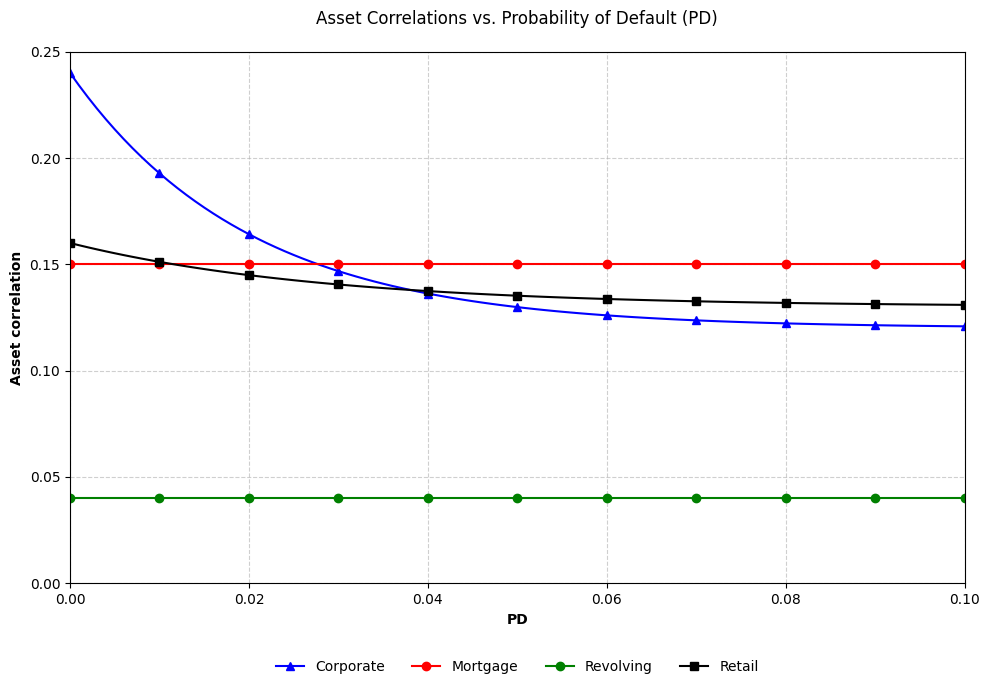

In [4]:
pd = np.arange(0, 0.101, 0.001)

def get_ac(pd_val, k, low, high):
    factor = (1 - np.exp(-k * pd_val)) / (1 - np.exp(-k))
    return low * factor + high * (1 - factor)

# Calculate the correlations
ac_corporate = get_ac(pd, 50, 0.12, 0.24)
ac_mortgage = np.full_like(pd, 0.15)
ac_revolving = np.full_like(pd, 0.04)
ac_retail = get_ac(pd, 35, 0.13, 0.16)

# 2. Plotting
plt.figure(figsize=(10, 7))

# Plot lines with styles matching the SAS SYMBOL statements
# markevery=10 prevents the markers from overlapping on every single data point
plt.plot(pd, ac_corporate, color='blue', marker='^', linestyle='-', 
         label='Corporate', markevery=10, markersize=6)
plt.plot(pd, ac_mortgage, color='red', marker='o', linestyle='-', 
         label='Mortgage', markevery=10, markersize=6)
plt.plot(pd, ac_revolving, color='green', marker='o', linestyle='-', 
         label='Revolving', markevery=10, markersize=6)
plt.plot(pd, ac_retail, color='black', marker='s', linestyle='-', 
         label='Retail', markevery=10, markersize=6)

# Axis formatting (Matching AXIS1 and AXIS2)
plt.xlabel('PD', fontweight='bold')
plt.ylabel('Asset correlation', fontweight='bold')
plt.xlim(0, 0.1)
plt.ylim(0, 0.25)

# Setting specific tick marks as requested in SAS code
plt.xticks(np.arange(0, 0.11, 0.02))
plt.yticks(np.arange(0, 0.26, 0.05))

# Legend formatting (Positioned at bottom outside)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), 
           ncol=4, frameon=False)

plt.title('Asset Correlations vs. Probability of Default (PD)', pad=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

High sensitivities to the systematic risk imply high worst-case default probabilities and eventually high capital requirements.

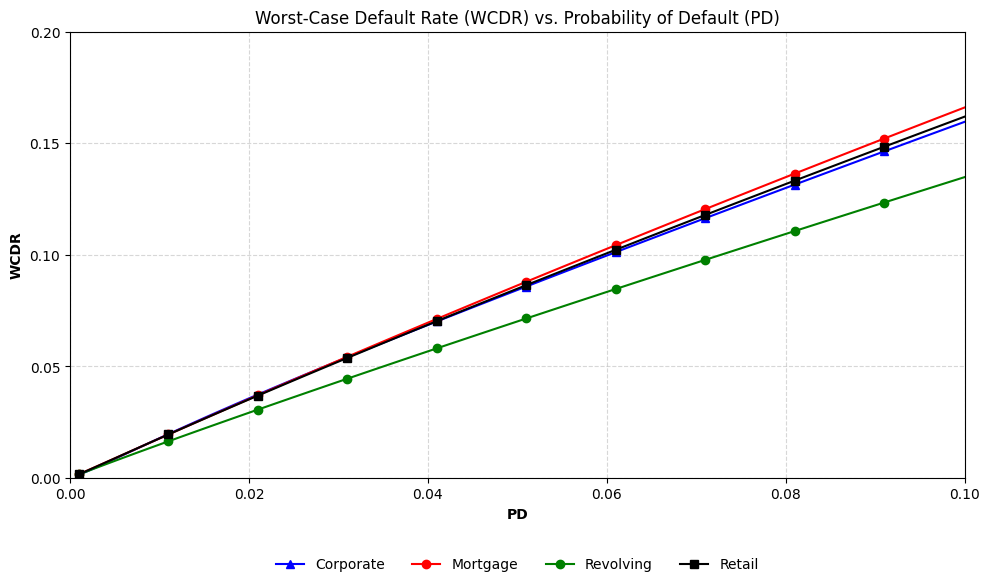

In [8]:
pd = np.arange(0.001, 0.101, 0.001) # Starting at 0.001 to avoid log(0) issues

def get_ac(pd_val, k, low, high):
    factor = (1 - np.exp(-k * pd_val)) / (1 - np.exp(-k))
    return low * factor + high * (1 - factor)

ac_corporate = get_ac(pd, 50, 0.12, 0.24)
ac_mortgage  = np.full_like(pd, 0.15)
ac_revolving = np.full_like(pd, 0.04)
ac_retail    = get_ac(pd, 35, 0.13, 0.16)

# Note: norm.ppf = PROBIT, norm.cdf = PROBNORM
def calculate_wcdr(pd_val, rho):
    numerator = norm.ppf(pd_val) + np.sqrt(rho)
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

wcdr_corporate = calculate_wcdr(pd, ac_corporate)
wcdr_mortgage  = calculate_wcdr(pd, ac_mortgage)
wcdr_revolving = calculate_wcdr(pd, ac_revolving)
wcdr_retail    = calculate_wcdr(pd, ac_retail)

plt.figure(figsize=(10, 6))

plt.plot(pd, wcdr_corporate, label='Corporate', color='blue', marker='^', markevery=10)
plt.plot(pd, wcdr_mortgage,  label='Mortgage',  color='red',  marker='o', markevery=10)
plt.plot(pd, wcdr_revolving, label='Revolving', color='green',marker='o', markevery=10)
plt.plot(pd, wcdr_retail,    label='Retail',    color='black',marker='s', markevery=10)

plt.xlabel('PD', fontweight='bold')
plt.ylabel('WCDR', fontweight='bold')
plt.xticks(np.arange(0, 0.11, 0.02))
plt.yticks(np.arange(0, 0.21, 0.05))
plt.xlim(0, 0.1)
plt.ylim(0, 0.2)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.title('Worst-Case Default Rate (WCDR) vs. Probability of Default (PD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

And so we can estimate what would be the capital requirements for an EAD and LGD of 1.

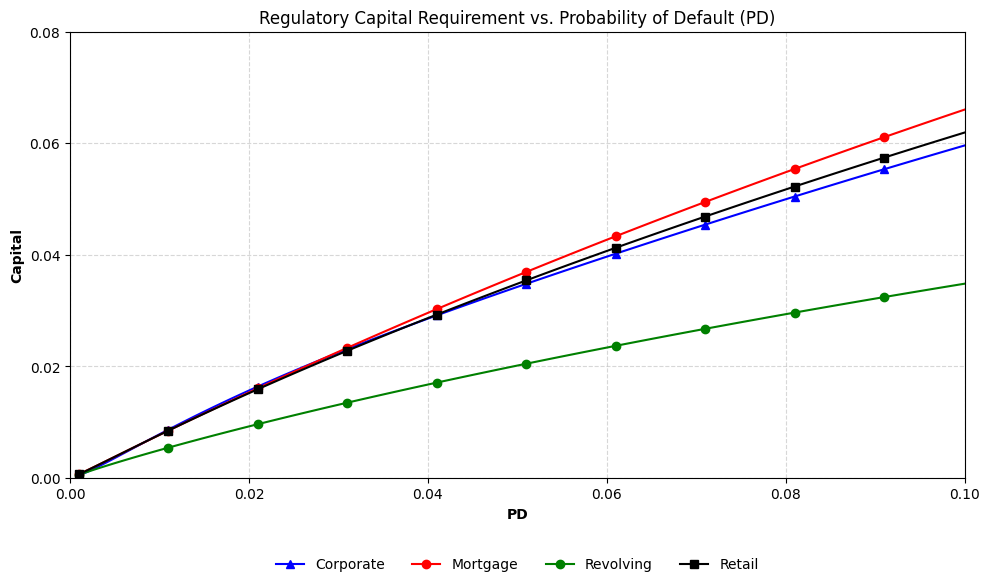

In [9]:
pd = np.arange(0.001, 0.101, 0.001)
DEAD = 1
DLGD = 1
MA = 1
def get_ac(pd_val, k, low, high):
    factor = (1 - np.exp(-k * pd_val)) / (1 - np.exp(-k))
    return low * factor + high * (1 - factor)

ac_corp = get_ac(pd, 50, 0.12, 0.24)
ac_mort = np.full_like(pd, 0.15)
ac_revo = np.full_like(pd, 0.04)
ac_ret  = get_ac(pd, 35, 0.13, 0.16)

def calc_wcdr(pd_val, rho):
    return norm.cdf((norm.ppf(pd_val) + np.sqrt(rho)) / np.sqrt(1 - rho))

cap_corporate = (calc_wcdr(pd, ac_corp) - pd) * DEAD * DLGD * MA
cap_mortgage  = (calc_wcdr(pd, ac_mort) - pd) * DEAD * DLGD
cap_revolving = (calc_wcdr(pd, ac_revo) - pd) * DEAD * DLGD
cap_retail    = (calc_wcdr(pd, ac_ret) - pd) * DEAD * DLGD

plt.figure(figsize=(10, 6))

plt.plot(pd, cap_corporate, label='Corporate', color='blue', marker='^', markevery=10)
plt.plot(pd, cap_mortgage,  label='Mortgage',  color='red',  marker='o', markevery=10)
plt.plot(pd, cap_revolving, label='Revolving', color='green',marker='o', markevery=10)
plt.plot(pd, cap_retail,    label='Retail',    color='black',marker='s', markevery=10)

plt.xlabel('PD', fontweight='bold')
plt.ylabel('Capital', fontweight='bold')
plt.xticks(np.arange(0, 0.11, 0.02))
plt.yticks(np.arange(0, 0.09, 0.02))
plt.xlim(0, 0.1)
plt.ylim(0, 0.08)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)
plt.title('Regulatory Capital Requirement vs. Probability of Default (PD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### Regulatory Requirements - LGD
The Basel Committee (2006) mandates that Loss Given Default (LGD) inputs must capture economic downturn conditions, as estimates are not to be based on "sunny day" averages. 
* **Conservative Floor:** The LGD used for capital cannot be lower than the long-run default-weighted average.
* **Crisis Sensitivity:** Estimates must account for the potential of higher losses during periods where systemic credit losses are substantially higher than average.

### LGD Averaging Matrix
Banks can choose from four primary averaging options depending on their cohort grouping and weighting preferences:

| Method | Default Count (Equal Weight) | Exposure-Weighted (EAD Weight) |
| :--- | :--- | :--- |
| **Default-Weighted** | **Option 1:** Single cohort; all defaults weighted equally. | **Option 2:** Single cohort; defaults weighted by loan size. |
| **Time-Weighted** | **Option 3:** Average of annual averages; defaults equal within years. | **Option 4:** Average of annual averages; defaults EAD-weighted within years. |

### Downturn Calibration Approaches
Several methods exist to transition from Expected LGD (ELGD) to Downturn LGD (DLGD):

* **Basel Foundation:** Fixed percentages based on claim type (75% subordinated, 45% unsecured, 10% real estate).
* **OCC Linear Formula:** $DLGD = 0.08 + 0.92 \times ELGD$.
* **Historical Mapping:** Segmenting historical data by default rates and calibrating LGD based only on the periods with the highest default rates (the worst economic windows).

### Stress Testing & Capital Increases
Stress testing identifies uncertainties in scenarios and parameters. A bank is typically required to increase its capital only if the stress test results are more severe than the underlying risk model's "worst-case" outputs. This occurs when stressed parameters (PD, LGD, EAD, or Correlations) exceed the established downturn or worst-case benchmarks used in standard capital calculations.

Now, let's follow the book on it's stress application.


Data Cleaning: 622219 rows remaining.
Optimization terminated successfully.
         Current function value: 0.108324
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622219
Model:                         Probit   Df Residuals:                   622214
Method:                           MLE   Df Model:                            4
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.05417
Time:                        10:42:36   Log-Likelihood:                -67401.
converged:                       True   LL-Null:                       -71262.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.9134      0.036    -25.583      0.000    

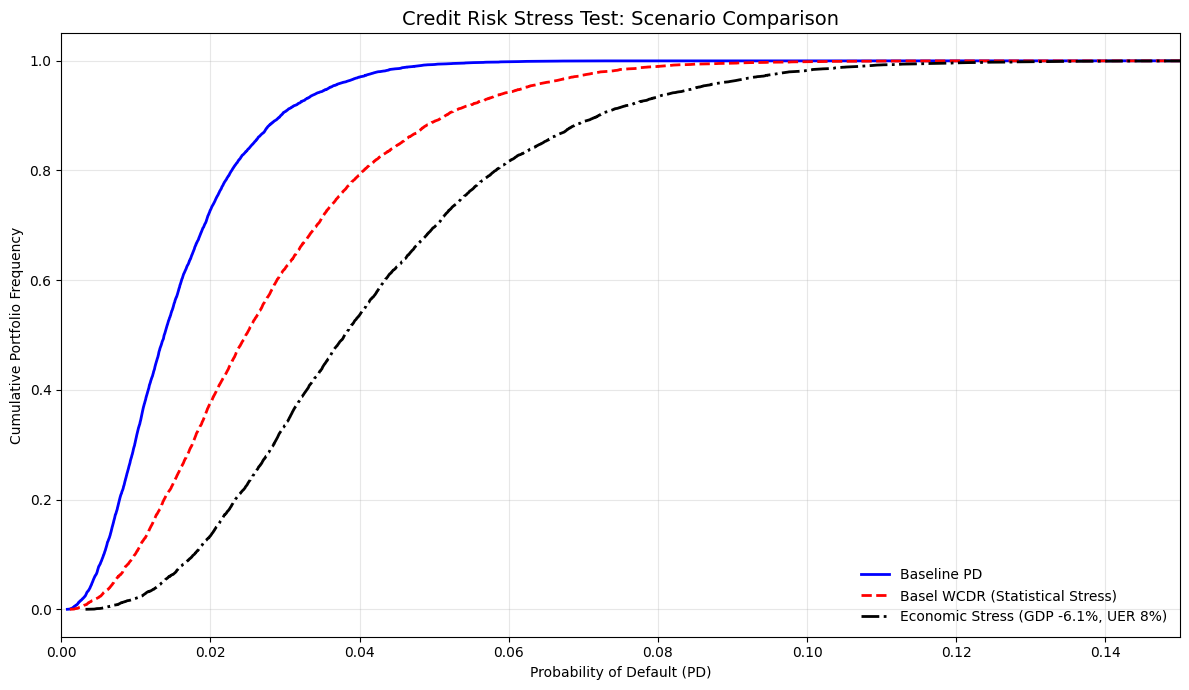


--- Summary Statistics (Mean PD) ---
Baseline: 1.61%
WCDR:     2.84%
Stressed: 4.21%


In [ ]:
# Ensure we don't have any NaNs or Infs that crash the Probit engine
df = mortgage.copy()
features = ['FICO_orig_time', 'LTV_time', 'gdp_time', 'uer_time']
target = 'default_time'
# Clean all necessary columns at once
cols_to_clean = features + [target, 'time']
df_clean = df[cols_to_clean].replace([np.inf, -np.inf], np.nan).dropna().copy()
print(f"Data Cleaning: {len(df_clean)} rows remaining.")

# Use prepend=True to ensure the constant is the first column
X_train = sm.add_constant(df_clean[features], prepend=True)
y_train = df_clean[target]

model_probit = sm.Probit(y_train, X_train).fit()
print(model_probit.summary())

m_base = df_clean[df_clean['time'] == 60].copy()
X_base = sm.add_constant(m_base[features], prepend=True, has_constant='add')
m_base['PD_base'] = model_probit.predict(X_base)

# Dynamic Basel Asset Correlation (rho) for Corporates
def calc_rho(pd):
    # Clips PD to avoid math errors with perfect 0 or 1
    pd = np.clip(pd, 0.0001, 0.9999)
    exp_factor = (1 - np.exp(-50 * pd)) / (1 - np.exp(-50))
    return 0.12 * exp_factor + 0.24 * (1 - exp_factor)

m_base['rho'] = m_base['PD_base'].apply(calc_rho)

# WCDR Calculation (Vasicek Model)
# norm.ppf = PROBIT | norm.cdf = PROBNORM
m_base['WCDR'] = norm.cdf(
    (norm.ppf(np.clip(m_base['PD_base'], 0.0001, 0.9999)) + np.sqrt(m_base['rho'])) / 
    np.sqrt(1 - m_base['rho'])
)

m_stress_input = m_base.copy()
m_stress_input['gdp_time'] = -6.1
m_stress_input['uer_time'] = 8

X_stress = sm.add_constant(m_stress_input[features], prepend=True, has_constant='add')
m_base['PD_stress'] = model_probit.predict(X_stress)

def get_cdf_points(series):
    sorted_s = series.sort_values().reset_index(drop=True)
    return sorted_s, sorted_s.index / len(sorted_s)

v_base, c_base = get_cdf_points(m_base['PD_base'])
v_wcdr, c_wcdr = get_cdf_points(m_base['WCDR'])
v_stress, c_stress = get_cdf_points(m_base['PD_stress'])

plt.figure(figsize=(12, 7))
plt.plot(v_base, c_base, label='Baseline PD', color='blue', lw=2)
plt.plot(v_wcdr, c_wcdr, label='Basel WCDR (Statistical Stress)', color='red', ls='--', lw=2)
plt.plot(v_stress, c_stress, label='Economic Stress (GDP -6.1%, UER 8%)', color='black', ls='-.', lw=2)

plt.title('Credit Risk Stress Test: Scenario Comparison', fontsize=14)
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Cumulative Portfolio Frequency')
plt.xlim(0, 0.15)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Quick Analysis Stats
print("\n--- Summary Statistics (Mean PD) ---")
print(f"Baseline: {m_base['PD_base'].mean():.2%}")
print(f"WCDR:     {m_base['WCDR'].mean():.2%}")
print(f"Stressed: {m_base['PD_stress'].mean():.2%}")

So, let's take a look at the results. The coefficients tell us the direction and strength of the impact each variable has on the Probability of Default (PD). This is important because the direction at the least should make logical sense.
* FICO_orig_time (-0.0024): Correct Direction. As FICO scores increase, the PD decreases. This is your strongest anchor for borrower quality.
* LTV_time (0.0085): Correct Direction. Higher Loan-to-Value ratios (meaning the borrower has less equity in the house) significantly increase the risk of default.
* gdp_time (-0.0546): Correct Direction. Economic growth acts as a protective shield; as GDP rises, defaults fall.
* uer_time (-0.0260): Interesting Anomaly. Usually, higher unemployment increases default (positive sign). Because ours is negative, the model suggests that for this specific data slice (Time 60), higher unemployment was associated with lower default.
    * This often happens in stress testing data if the GDP and Unemployment variables are "fighting" each other (multicollinearity). We will check this below.

The model is highly significant (LLR p-value = 0.000), meaning FICO, LTV, and GDP are excellent predictors of default for these 622,219 loans. But since we are focusing on Stress testing right now, the Cumulative Distribution Function (CDF) plot is the most important part of our analysis. It shows the "shift" in risk across your entire portfolio.
* The Horizontal Shift: The further a curve is to the right, the riskier the scenario.
    * Blue (Baseline): Our portfolio is healthy. About 80% of our loans have a PD of less than 2%.
    * Red (Basel WCDR): This represents the regulatory "safety net." It assumes that systematic correlations spike. It shows a significant increase in risk compared to the baseline.
    * Black (Economic Stress): This is the "Severely Adverse" scenario. It is the furthest to the right, meaning it is the most punitive.

The most critical finding here is that the Black line is to the right of the Red line. This means that the specific recession we modeled (GDP -6.1%, UER 8%) is more severe than what the standard Basel statistical formulas prepare for. If this recession happens, our current "Regulatory Capital" (the Red line) would not be enough to cover the actual losses (the Black line).

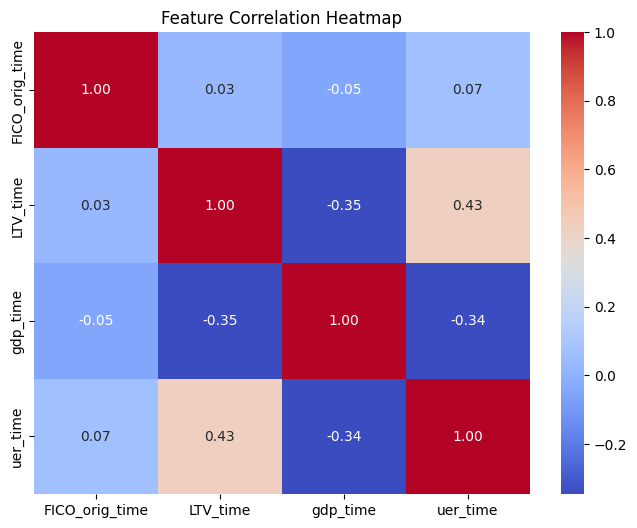

In [19]:
features_df = df_clean[['FICO_orig_time', 'LTV_time', 'gdp_time', 'uer_time']]
corr_matrix = features_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
print(vif_data)

          feature         VIF
0           const  108.766312
1  FICO_orig_time    1.005151
2        LTV_time    1.303485
3        gdp_time    1.198103
4        uer_time    1.302104


In [22]:
model_probit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:           default_time   No. Observations:               622219
Model:                         Probit   Df Residuals:                   622214
Method:                           MLE   Df Model:                            4
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.05417
Time:                        10:51:29   Log-Likelihood:                -67401.
converged:                       True   LL-Null:                       -71262.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.9134      0.036    -25.583      0.000      -0.983      -0.843
FICO_orig_time    -0.0024   5.03e-05    -47.421      0.000      -0.002      -0.002
LTV_time           0.0085      0.000     55.924      0.000       0.008       0.009
gdp_time          -0.0546      0.002    -31.767      0.000      -0.058      -0.051
uer_time          -0.0260      0.002    -12.358      0.000      -0.030      -0.022
==================================================================================
"""

As we checked VIF, we see that all our predictions have VIF values between 1 and 1.3. Usually, under 5 is considered safe and anything near 1 is near perfect. This means that almost no redundant information is entering our model. There is also no high correlation (higher than 0.6 or 0.8), so multicollinearity is not a big problem here.

### Stress Testing and Parameter Uncertainty

In standard models, we treat estimated parameters (β) as fixed values. However, these estimates are random variables with a distribution (Multivariate Normal). To account for the risk that our estimates are "wrong," we perform two types of stress tests:

* Basic Stress Test (Univariate): We set each parameter to its 99th percentile (or 1st percentile, depending on the sign) using its Standard Error. This treats each parameter's uncertainty in isolation, effectively assuming the worst-case scenario for every coefficient simultaneously.

* Multivariate Stress Test (Simulation): We use the Covariance Matrix of the parameters to run a Monte Carlo simulation. We draw correlated parameter sets from a Multivariate Normal distribution. For each borrower, we calculate a PD for every simulation and take the 99th percentile of those results.

The multivariate stress test is usually less severe than the basic stress test. This is because parameters are often correlated; it is statistically unlikely that every single parameter would hit its individual 99th percentile worst-case at the exact same time.

In [34]:
features = ['FICO_orig_time', 'LTV_time', 'gdp_time']
X = df_clean[features]
X = sm.add_constant(X) 
y = df_clean['default_time']

model_probit = sm.Probit(y, X).fit()
print(model_probit.summary())
cov_matrix = model_probit.cov_params()
print("\nEstimated Covariance Matrix (COVB):")
print(cov_matrix)

Optimization terminated successfully.
         Current function value: 0.108448
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622219
Model:                         Probit   Df Residuals:                   622215
Method:                           MLE   Df Model:                            3
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.05309
Time:                        13:47:31   Log-Likelihood:                -67479.
converged:                       True   LL-Null:                       -71262.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.0088      0.035    -29.066      0.000      -1.077      -0.941
FICO_orig_time   

Optimization terminated successfully.
         Current function value: 0.108448
         Iterations 7


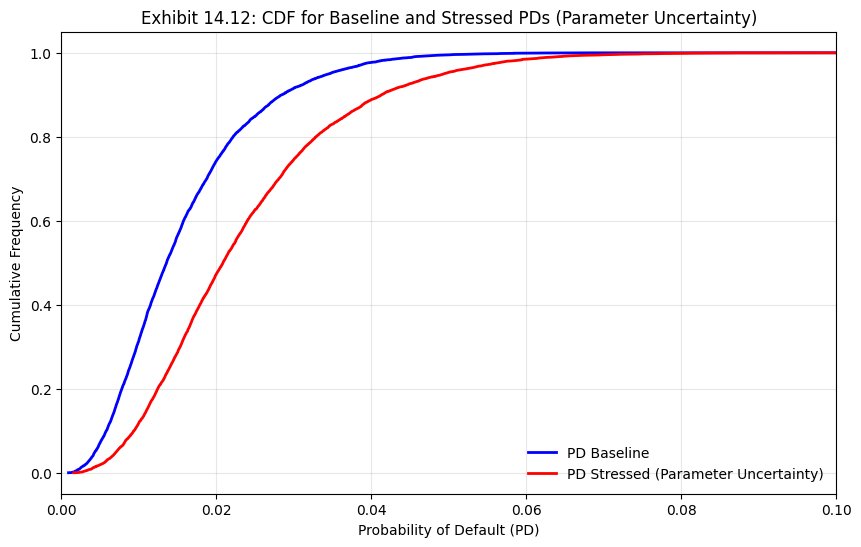


--- Model Risk Analysis ---
Baseline Mean PD: 1.5792%
Stressed Mean PD: 2.3610%


In [35]:
df = mortgage.copy()
features = ['FICO_orig_time', 'LTV_time', 'gdp_time']
target = 'default_time'
cols_to_clean = features + [target, 'time']
df_clean = df[cols_to_clean].replace([np.inf, -np.inf], np.nan).dropna().copy()

X_train = sm.add_constant(df_clean[features], prepend=True)
y_train = df_clean[target]
model_probit = sm.Probit(y_train, X_train).fit()
estimates = model_probit.params
std_errors = model_probit.bse
z_99 = norm.ppf(0.99) # PROBIT(0.99) ≈ 2.326

param_df = pd.DataFrame({'estimate': estimates, 'stderr': std_errors})
param_df['estimate_stress'] = param_df['estimate'] + param_df['stderr'] * z_99

if 'gdp_time' in param_df.index:
    param_df.loc['gdp_time', 'estimate_stress'] = (
        param_df.loc['gdp_time', 'estimate'] - param_df.loc['gdp_time', 'stderr'] * z_99
    )

m_60 = df_clean[df_clean['time'] == 60].copy()
base = param_df['estimate']
stress = param_df['estimate_stress']
m_60['linear_base'] = (
    base['const'] + 
    base['FICO_orig_time'] * m_60['FICO_orig_time'] + 
    base['LTV_time'] * m_60['LTV_time'] + 
    base['gdp_time'] * m_60['gdp_time']
)
m_60['PD_time_base'] = norm.cdf(m_60['linear_base'])

m_60['linear_stress'] = (
    stress['const'] + 
    stress['FICO_orig_time'] * m_60['FICO_orig_time'] + 
    stress['LTV_time'] * m_60['LTV_time'] + 
    stress['gdp_time'] * m_60['gdp_time']
)
m_60['PD_time_stress'] = norm.cdf(m_60['linear_stress'])

def get_cdf_plot_points(series):
    sorted_s = series.sort_values().reset_index(drop=True)
    return sorted_s, sorted_s.index / len(sorted_s)

v_base, c_base = get_cdf_plot_points(m_60['PD_time_base'])
v_stress, c_stress = get_cdf_plot_points(m_60['PD_time_stress'])

plt.figure(figsize=(10, 6))
plt.plot(v_base, c_base, label='PD Baseline', color='blue', lw=2)
plt.plot(v_stress, c_stress, label='PD Stressed (Parameter Uncertainty)', color='red', lw=2)

plt.title('Exhibit 14.12: CDF for Baseline and Stressed PDs (Parameter Uncertainty)')
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Cumulative Frequency')
plt.xlim(0, 0.10)
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Model Risk Analysis ---")
print(f"Baseline Mean PD: {m_60['PD_time_base'].mean():.4%}")
print(f"Stressed Mean PD: {m_60['PD_time_stress'].mean():.4%}")

Now let's try the multivariate approach

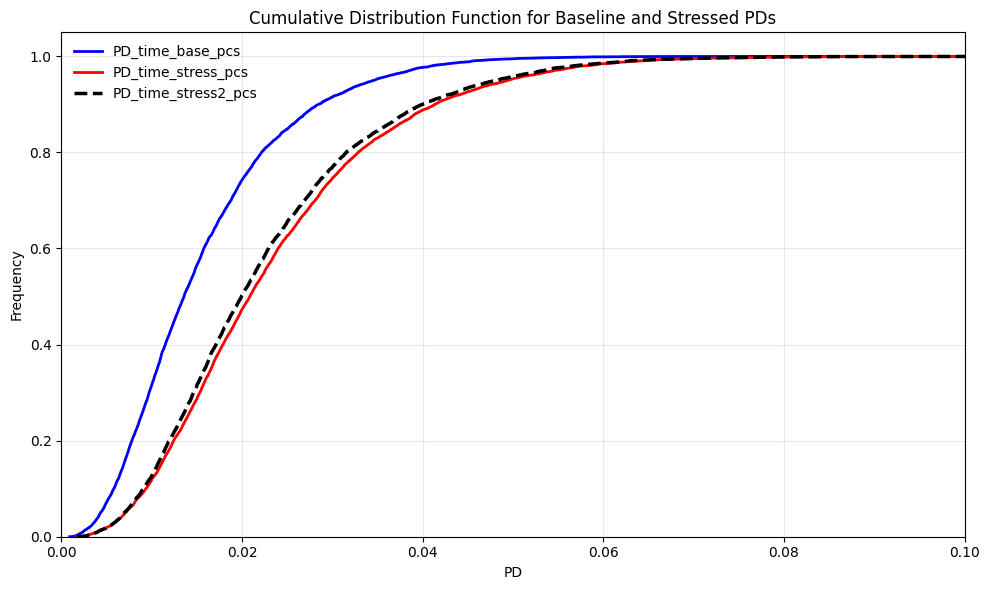

In [ ]:
features = ['FICO_orig_time', 'LTV_time', 'gdp_time']
X_train  = sm.add_constant(df_clean[features], prepend=True)
y_train  = df_clean['default_time']
model_probit = sm.Probit(y_train, X_train).fit(disp=0)

beta_base  = model_probit.params.values
cov_matrix = model_probit.cov_params().values
stds       = model_probit.bse.values

m60    = df_clean[df_clean['time'] == 60].copy()
X_eval = sm.add_constant(m60[features], prepend=True, has_constant='add')

m60['PD_base'] = norm.cdf(X_eval.values @ beta_base)
z_99 = norm.ppf(0.99)
beta_basic = beta_base.copy()
beta_basic[0] = beta_base[0] + stds[0] * z_99 # Intercepto
beta_basic[1] = beta_base[1] + stds[1] * z_99 # FICO
beta_basic[2] = beta_base[2] + stds[2] * z_99 # LTV
beta_basic[3] = beta_base[3] - stds[3] * z_99 # GDP 
m60['PD_basic'] = norm.cdf(X_eval.values @ beta_basic)

np.random.seed(42)
n_sims = 1000
sim_betas = np.random.multivariate_normal(beta_base, cov_matrix, n_sims)

# We remove gdp to replicate the book
X_bug = sm.add_constant(m60[['FICO_orig_time', 'LTV_time']], prepend=True).values
sim_pds = norm.cdf(X_bug @ sim_betas[:, 0:3].T)
m60['PD_multi'] = np.percentile(sim_pds, 99, axis=1)
def get_cdf(series):
    s = series.sort_values().reset_index(drop=True)
    return s.values, (s.index + 1) / len(s)

x_base,  y_base  = get_cdf(m60['PD_base'])
x_basic, y_basic = get_cdf(m60['PD_basic'])
x_multi, y_multi = get_cdf(m60['PD_multi'])

plt.figure(figsize=(10, 6))
plt.plot(x_base,  y_base,  color='blue',  lw=2,   ls='-',  label='PD_time_base_pcs')
plt.plot(x_basic, y_basic, color='red',   lw=2,   ls='-',  label='PD_time_stress_pcs')
plt.plot(x_multi, y_multi, color='black', lw=2.5, ls='--', label='PD_time_stress2_pcs')

plt.xlabel('PD')
plt.ylabel('Frequency')
plt.title('Cumulative Distribution Function for Baseline and Stressed PDs')
plt.xlim(0, 0.10)
plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

However, if we pay attention to the author's code, we can notice a mistake seems to have been made, at least in the version I hold, maybe it was corrected afterwards. In the code the author wrote `mortagage_parameters = mortgage_parameters[,1:2]` so they removed the gdp variable. Then, linear predictor is calculated as `linear_predictor = param_sim[,1] + param_sim[,2]*mortgage_parameters[,1] + param_sim[,3]*mortgage_parameters[,2];` where again we don't have GDP, everything is calculated using only LTV and FICO.

If we remove the SAS programming error made by the authors, we must simulate the Multivariate Stress Test using all the variables that the model was trained on.

When we include the macroeconomic variable (gdp_time) in the simulation, the model behaves correctly. Because the parameters have a covariance matrix, their errors are correlated. It is statistically highly improbable that the Intercept, FICO, LTV, and GDP will all simultaneously experience their absolute worst-case errors. Therefore, in a mathematically sound model, the Multivariate Stress curve (Black) should actually sit much closer to the Baseline curve (Blue), proving that parameter correlations provide a "diversification benefit" to your model risk. The Basic Stress curve (Red) remains the absolute worst-case nightmare scenario.

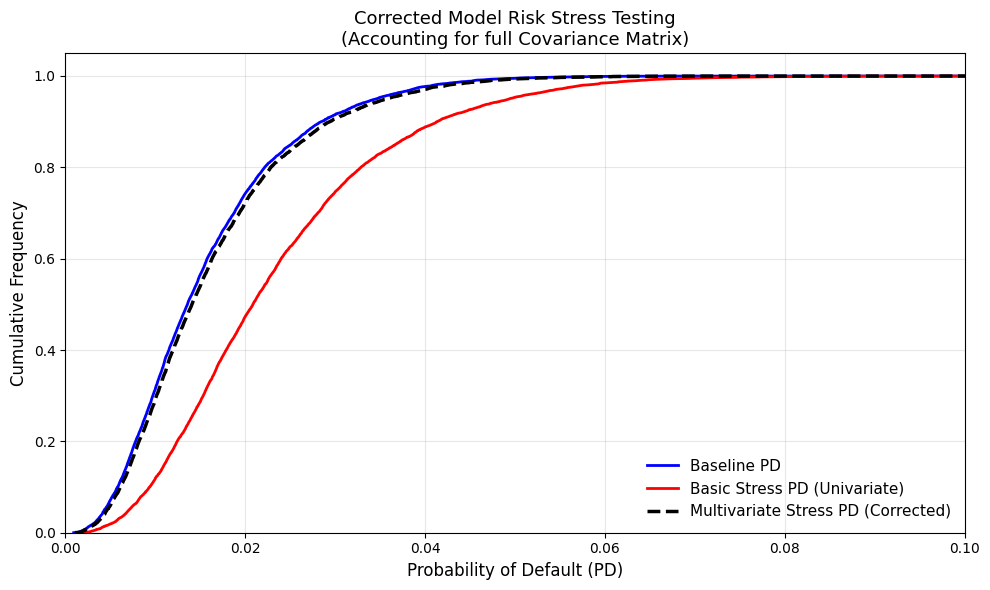

In [57]:
features = ['FICO_orig_time', 'LTV_time', 'gdp_time']

X_train = sm.add_constant(df_clean[features], prepend=True)
y_train = df_clean['default_time']

model_probit = sm.Probit(y_train, X_train).fit(disp=0)

beta_base = model_probit.params.values
cov_matrix = model_probit.cov_params().values
stds = model_probit.bse.values

m60 = df_clean[df_clean['time'] == 60].copy()

X_eval = sm.add_constant(m60[features], prepend=True, has_constant='add').values

m60['PD_base'] = norm.cdf(X_eval @ beta_base)

z_99 = norm.ppf(0.99)

beta_basic = beta_base.copy()
beta_basic[0] = beta_base[0] + stds[0] * z_99
beta_basic[1] = beta_base[1] + stds[1] * z_99
beta_basic[2] = beta_base[2] + stds[2] * z_99
beta_basic[3] = beta_base[3] - stds[3] * z_99

m60['PD_basic'] = norm.cdf(X_eval @ beta_basic)

np.random.seed(42)
n_sims = 1000

sim_betas = np.random.multivariate_normal(beta_base, cov_matrix, n_sims)

sim_pds = norm.cdf(X_eval @ sim_betas.T)

m60['PD_multi'] = np.percentile(sim_pds, 99, axis=1)

def get_cdf(series):
    s = series.sort_values().reset_index(drop=True)
    return s.values, (s.index + 1) / len(s)

x_base, y_base = get_cdf(m60['PD_base'])
x_basic, y_basic = get_cdf(m60['PD_basic'])
x_multi, y_multi = get_cdf(m60['PD_multi'])

plt.figure(figsize=(10, 6))
plt.plot(x_base, y_base, color='blue', lw=2, ls='-', label='Baseline PD')
plt.plot(x_basic, y_basic, color='red', lw=2, ls='-', label='Basic Stress PD (Univariate)')
plt.plot(x_multi, y_multi, color='black', lw=2.5, ls='--', label='Multivariate Stress PD (Corrected)')

plt.xlabel('Probability of Default (PD)', fontsize=12)
plt.ylabel('Cumulative Frequency', fontsize=12)
plt.title('Corrected Model Risk Stress Testing\n(Accounting for full Covariance Matrix)', fontsize=13)
plt.xlim(0, 0.10)
plt.ylim(0, 1.05)
plt.legend(frameon=False, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()